In [1]:
# !pip install telonex
from telonex import get_dataframe, download

In [69]:
import os
from datetime import datetime, timedelta
import pandas as pd
from pathlib import Path
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
from zoneinfo import ZoneInfo

In [3]:
mkt_df = pd.read_parquet("../datasets/polymarket_markets.parquet")

In [4]:
mkt_df.head(5)

,exchange,market_id,slug,event_id,event_slug,event_title,question,description,category,outcome_0,...,quotes_from,quotes_to,book_snapshot_5_from,book_snapshot_5_to,book_snapshot_25_from,book_snapshot_25_to,book_snapshot_full_from,book_snapshot_full_to,onchain_fills_from,onchain_fills_to
0,polymarket,0x467022bb219ee9b887ee30d71d2fcd7fe167103734f2...,lol-zena-ae2-2026-05-01-game-handicap-home-1pt5,437281,lol-zena-ae2-2026-05-01,LoL: Zena Esports vs Aeterna Esports (BO5) - L...,Game Handicap: AE (-1.5) vs Zena Esports (+1.5),This market refers to the LoL Lower bracket ro...,,Aeterna Esports,...,2026-05-01,2026-05-03,2026-05-01,2026-05-03,2026-05-01,2026-05-03,2026-05-01,2026-05-03,2026-05-01,2026-05-02
1,polymarket,0x71a16036517a496f27b394718884d023a595a48d5586...,fl1-pfc-sbr-2026-05-03-exact-score-4-2,398102,fl1-pfc-sbr-2026-05-03-exact-score,Paris FC vs. Stade Brestois 29 - Exact Score,Exact Score: Paris FC 4 - 2 Stade Brestois 29?,In the upcoming Ligue 1 game between Paris FC ...,,Yes,...,2026-04-20,2026-05-04,2026-04-20,2026-05-04,2026-04-20,2026-05-04,2026-04-20,2026-05-04,,
2,polymarket,0xf9b3d64289d23b9c0bc7d3228dff1348107450b388b5...,,,,,,,,,...,,,,,,,,,,
3,polymarket,0x448b030b6d1172302e2ac4879e3d006e0542dc90a8f8...,,,,,,,,,...,,,,,,,,,,
4,polymarket,0x85d4f800924b0eaa45a7a7447bf51f0caae8e1c979cb...,btc-updown-5m-1777033800,409754,btc-updown-5m-1777033800,"Bitcoin Up or Down - April 24, 8:30AM-8:35AM ET","Bitcoin Up or Down - April 24, 8:30AM-8:35AM ET","This market will resolve to ""Up"" if the Bitcoi...",,Up,...,2026-04-23,2026-04-25,2026-04-23,2026-04-25,2026-04-23,2026-04-25,2026-04-23,2026-04-25,2026-04-24,2026-04-25


In [9]:
nba_tags = sorted({

    tag

    for tags in mkt_df["tags"].dropna()

    for tag in np.asarray(tags).ravel()

    if isinstance(tag, str) and "nba" in tag.lower()

})

nba_tags

['2026-nba-all-star',
 '2026-nba-all-star-game',
 '2026-nba-draft',
 '2026-nba-draft-lottery',
 '2026-nba-playoffs',
 '2026-nba-rising-stars',
 '2026-nba-western-conference-finals',
 '2026-wnba-playoffs',
 'all-nba',
 'claudia-sheinbaum',
 'coinbase',
 'donbas',
 'donbass',
 'nba',
 'nba-all-star',
 'nba-all-star-game',
 'nba-all-star-weekend',
 'nba-champion',
 'nba-championship',
 'nba-cup',
 'nba-draft',
 'nba-finals',
 'nba-playoffs',
 'nba-rising-stars',
 'wnba',
 'wnba-finals']

In [5]:
filtered_df = mkt_df[mkt_df["tags"].apply(lambda x: "2026-nba-playoffs" in x)]
filtered_df

,exchange,market_id,slug,event_id,event_slug,event_title,question,description,category,outcome_0,...,quotes_from,quotes_to,book_snapshot_5_from,book_snapshot_5_to,book_snapshot_25_from,book_snapshot_25_to,book_snapshot_full_from,book_snapshot_full_to,onchain_fills_from,onchain_fills_to
1960,polymarket,0xbbf3418f51b370c98f1d043cfcad73f64ac7b1a8ffc5...,will-og-anunoby-lead-the-2026-nba-finals-in-3-...,555194,nba-finals-total-3pm-leader,NBA Finals: Total 3PM Leader,Will OG Anunoby lead the 2026 NBA Finals in 3-...,This market will resolve in favor of the playe...,,Yes,...,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-03,2026-06-07
2014,polymarket,0xb374ade62efdf2d6914d6fa1d0078eb2f620b6fe2847...,will-player-r-win-the-2026-western-conference-...,375802,nba-playoffs-western-conference-finals-mvp,NBA Playoffs: Western Conference Finals MVP,Will Player R win the 2026 Western Conference ...,This market will resolve to the player who win...,,Yes,...,2026-05-17,2026-06-01,2026-05-17,2026-06-01,2026-05-17,2026-06-01,2026-05-17,2026-06-01,2026-05-19,2026-05-28
6265,polymarket,0xedc4ea0a80f3fc6324b95a9d64251381b807255489d9...,will-carter-bryant-lead-the-2026-nba-finals-in...,560508,nba-finals-total-points-leader-20260603024024282,NBA Finals: Total Points Leader,Will Carter Bryant lead the 2026 NBA Finals in...,This market will resolve in favor of the playe...,,Yes,...,2026-06-05,2026-06-08,2026-06-05,2026-06-08,2026-06-05,2026-06-08,2026-06-05,2026-06-08,2026-06-05,2026-06-08
10870,polymarket,0x9b6eaeeda644e1cb4d0345d9b46a235c13f324b6562d...,will-player-e-lead-the-2026-nba-finals-in-tota...,560435,nba-finals-total-rebounds-leader-2026060302402...,NBA Finals: Total Rebounds Leader,Will Player E lead the 2026 NBA Finals in tota...,This market will resolve in favor of the playe...,,Yes,...,,,,,,,,,,
12630,polymarket,0x298157e618b5729dafd742eec9b21e040a13da0bb09f...,will-the-utah-jazz-win-the-2026-nba-finals,27830,2026-nba-champion,2026 NBA Champion,Will the Utah Jazz win the 2026 NBA Finals?,This market will resolve to “Yes” if the Utah ...,,Yes,...,2025-10-11,2026-03-20,2025-10-11,2026-03-20,2025-10-11,2026-03-20,2025-10-11,2026-03-20,2025-06-29,2026-03-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1578159,polymarket,0x0f439cf8fc09856a95dda7e0f2a4299044cb7e5abae8...,will-tim-duncan-attend-any-game-at-the-2026-nb...,551757,nba-playoffs-who-will-attend-the-nba-finals,NBA Playoffs: Who will attend the NBA Finals?,Will Tim Duncan attend any game at the 2026 NB...,"The 2026 NBA Finals are scheduled for June 3, ...",,Yes,...,2026-06-02,2026-06-06,2026-06-02,2026-06-06,2026-06-02,2026-06-06,2026-06-02,2026-06-06,2026-06-02,2026-06-06
1579817,polymarket,0x8afcf7b40b763d9ae80559b6b973023bdb32e9d6ef55...,will-player-ak-win-the-2026-eastern-conference...,375768,nba-playoffs-eastern-conference-finals-mvp,NBA Playoffs: Eastern Conference Finals MVP,Will Player AK win the 2026 Eastern Conference...,This market will resolve to the player who win...,,Yes,...,,,,,,,,,,
1580449,polymarket,0x508f1fcfc89f9337c6189181991590521a965a558ea9...,will-there-be-a-different-number-of-games-play...,556308,nba-finals-exact-series-length,NBA Finals: Exact Series Length,Will there be a different number of games play...,This market will resolve according to the numb...,,Yes,...,,,,,,,,,,
1582258,polymarket,0x414ca07f8900b427b5941f50fcb04563a65402dff606...,will-knicks-win-the-2026-nba-finals-4-2-be-the...,556284,nba-playoffs-finals-exact-outcome,NBA Playoffs: Finals Exact Outcome,Will Knicks win the 2026 NBA Finals 4-2 be the...,This market will resolve according to the exac...,,Yes,...,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-04,2026-06-08


In [12]:
filtered_df[filtered_df["tags"].apply(lambda x: "lakers" in x)]


,exchange,market_id,slug,event_id,event_slug,event_title,question,description,category,outcome_0,...,quotes_from,quotes_to,book_snapshot_5_from,book_snapshot_5_to,book_snapshot_25_from,book_snapshot_25_to,book_snapshot_full_from,book_snapshot_full_to,onchain_fills_from,onchain_fills_to
70148,polymarket,0x0b7b858bcd484321e2d605e1baca78d4c05500dbd173...,nba-playoffs-thunder-vs-lakers-total-games-ou-...,441249,nba-playoffs-thunder-vs-lakers-total-games-ou-...,NBA Playoffs: Thunder vs. Lakers Total Games O...,NBA Playoffs: Thunder vs. Lakers Total Games O...,This market will resolve to “Over” if more tha...,,Over 5.5,...,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13
100267,polymarket,0x6a251873cf1b1960d1b666ed0e7e2578ccc94b481d10...,nba-playoffs-rockets-vs-lakers-total-games-ou-...,375915,nba-playoffs-rockets-vs-lakers-total-games-ou-...,NBA Playoffs: Rockets vs. Lakers Total Games O...,NBA Playoffs: Rockets vs. Lakers Total Games O...,This market will resolve to “Over” if more tha...,,Over 5.5,...,2026-04-13,2026-05-03,2026-04-13,2026-05-03,2026-04-13,2026-05-03,2026-04-13,2026-05-03,2026-04-14,2026-05-03
1103209,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,441257,nba-playoffs-who-will-win-series-thunder-vs-la...,NBA Playoffs: Who Will Win Series? - Thunder v...,NBA Playoffs: Who Will Win Series? - Thunder v...,This market will resolve to “Thunder” if the O...,,Thunder,...,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13
1513732,polymarket,0x13b1bfb4d3d001814cc7c7dcecbd2de54befc1a33dc1...,nba-playoffs-who-will-win-series-lakers-vs-roc...,388968,nba-playoffs-who-will-win-series-lakers-vs-roc...,NBA Playoffs: Who Will Win Series? - Lakers vs...,NBA Playoffs: Who Will Win Series? - Lakers vs...,This market will resolve to “Lakers” if the Lo...,,Lakers,...,2026-04-17,2026-05-03,2026-04-17,2026-05-03,2026-04-17,2026-05-03,2026-04-17,2026-05-03,2026-04-17,2026-05-03


In [13]:
df = pd.read_parquet("/Users/zoujing/Desktop/Stanford/Spring 2026/Trading/final_proj/MS&E242_final/data/raw/book_snapshot_25/nba_playoffs_who_will_win_series_thunder_vs_lakers__Thunder/polymarket_book_snapshot_25_2026-05-02_nba-playoffs-who-will-win-series-thunder-vs-lakers_Thunder.parquet")

In [15]:
df.head(5)

,timestamp_us,local_timestamp_us,exchange,market_id,slug,asset_id,outcome,bid_price_0,bid_size_0,bid_price_1,...,ask_price_20,ask_size_20,ask_price_21,ask_size_21,ask_price_22,ask_size_22,ask_price_23,ask_size_23,ask_price_24,ask_size_24
0,1777728715639000,1777728715704122,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,0.01,100,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1777728715982000,1777728715991501,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,0.01,130,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1777728728632000,1777728728694718,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,0.01,693,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1777728729174000,1777728729181174,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,0.01,693,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1777728790003000,1777728790011754,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,0.02,200,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [147]:
N_LEVELS = 10
RAW_DIR = Path("../data/raw")
CHANNEL = "book_snapshot_25"
def load_clean_book(slug, outcome, n_levels=N_LEVELS):
    """Load the top n_levels of a contract's order book; return a time-sorted, numeric
    DataFrame that includes a mid-price column.

    Missing-level fill rules (so the OF three-case test is numerically self-consistent):
      missing bid price -> 0.0 (probability lower bound) ; missing ask price -> 1.0 (upper bound)
      any missing size  -> 0.0 (no resting order)
    mid is computed from the raw best level; rows with a missing best bid/ask are dropped
    (mid is undefined there).
    """
    folder = RAW_DIR / CHANNEL / f"{slug.replace('-', '_')}__{outcome}"
    files = sorted(folder.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(folder)

    # Only read the columns we need: top n_levels of price/size (bid + ask).
    cols = ["timestamp_us"]
    for i in range(n_levels):
        cols += [f"bid_price_{i}", f"bid_size_{i}", f"ask_price_{i}", f"ask_size_{i}"]

    df = pd.concat([pd.read_parquet(f, columns=cols) for f in files], ignore_index=True)
    df["ts"] = pd.to_datetime(df["timestamp_us"], unit="us", utc=True)
    df = df.sort_values("ts").reset_index(drop=True)
    # Remove duplicate timestamps: keep the last book state within each microsecond.
    # ~7–10% of rows are exact or near-simultaneous duplicates emitted by Telonex.
    n_before = len(df)
    df = df.drop_duplicates(subset=["ts"], keep="last").reset_index(drop=True)
    if len(df) < n_before:
        pass  # duplicates silently dropped; caller can log if needed

    # Coerce to numeric (Telonex stores price/size as strings; empty levels are NaN).
    price_size_cols = [c for c in cols if c != "timestamp_us"]
    for c in price_size_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Drop rows where best level is missing OR the book is inverted (bid >= ask).
    # Inverted rows (~0.03–0.63% per market) are invalid LOB states from Telonex.
    df = df.dropna(subset=["bid_price_0", "ask_price_0"]).reset_index(drop=True)
    df = df[df["bid_price_0"] < df["ask_price_0"]].reset_index(drop=True)
    df["mid"] = (df["bid_price_0"] + df["ask_price_0"]) / 2

    # Fill deeper-level missing values.
    for i in range(n_levels):
        df[f"bid_price_{i}"] = df[f"bid_price_{i}"].fillna(0.0)
        df[f"ask_price_{i}"] = df[f"ask_price_{i}"].fillna(1.0)
        df[f"bid_size_{i}"]  = df[f"bid_size_{i}"].fillna(0.0)
        df[f"ask_size_{i}"]  = df[f"ask_size_{i}"].fillna(0.0)
    return df

In [22]:
clean_df

,timestamp_us,bid_price_0,bid_size_0,ask_price_0,ask_size_0,bid_price_1,bid_size_1,ask_price_1,ask_size_1,bid_price_2,...,bid_price_8,bid_size_8,ask_price_8,ask_size_8,bid_price_9,bid_size_9,ask_price_9,ask_size_9,ts,mid
0,1777728715639000,0.010,100.0,0.990,100.0,0.000,0.0,1.0,0.0,0.000,...,0.000,0.00,1.0,0.0,0.000,0.00,1.0,0.0,2026-05-02 13:31:55.639000+00:00,0.5000
1,1777728715982000,0.010,130.0,0.990,100.0,0.000,0.0,1.0,0.0,0.000,...,0.000,0.00,1.0,0.0,0.000,0.00,1.0,0.0,2026-05-02 13:31:55.982000+00:00,0.5000
2,1777728728632000,0.010,693.0,0.990,100.0,0.000,0.0,1.0,0.0,0.000,...,0.000,0.00,1.0,0.0,0.000,0.00,1.0,0.0,2026-05-02 13:32:08.632000+00:00,0.5000
3,1777728729174000,0.010,693.0,0.990,663.0,0.000,0.0,1.0,0.0,0.000,...,0.000,0.00,1.0,0.0,0.000,0.00,1.0,0.0,2026-05-02 13:32:09.174000+00:00,0.5000
4,1777728790003000,0.020,200.0,0.990,663.0,0.010,693.0,1.0,0.0,0.000,...,0.000,0.00,1.0,0.0,0.000,0.00,1.0,0.0,2026-05-02 13:33:10.003000+00:00,0.5050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45371,1778563068319000,0.992,500.0,0.999,14.0,0.988,40.0,1.0,0.0,0.987,...,0.950,200.00,1.0,0.0,0.941,54.99,1.0,0.0,2026-05-12 05:17:48.319000+00:00,0.9955
45372,1778563281927000,0.992,500.0,0.999,1000.0,0.988,40.0,1.0,0.0,0.987,...,0.941,54.99,1.0,0.0,0.940,31.12,1.0,0.0,2026-05-12 05:21:21.927000+00:00,0.9955
45373,1778563281972000,0.992,500.0,0.999,995.0,0.988,40.0,1.0,0.0,0.987,...,0.941,54.99,1.0,0.0,0.940,31.12,1.0,0.0,2026-05-12 05:21:21.972000+00:00,0.9955
45374,1778563283965000,0.992,500.0,0.999,995.0,0.988,40.0,1.0,0.0,0.987,...,0.940,31.12,1.0,0.0,0.931,2125.00,1.0,0.0,2026-05-12 05:21:23.965000+00:00,0.9955


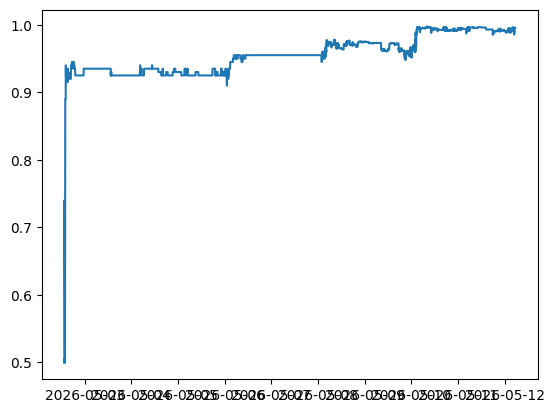

In [29]:
# filtered_clean_df = clean_df[(clean_df["ts"] >= "2026-05-09") & (clean_df["ts"] <= "2026-05-10")]
plt.plot(clean_df["ts"], clean_df["mid"])

In [27]:
filtered_clean_df

,timestamp_us,bid_price_0,bid_size_0,ask_price_0,ask_size_0,bid_price_1,bid_size_1,ask_price_1,ask_size_1,bid_price_2,...,bid_price_8,bid_size_8,ask_price_8,ask_size_8,bid_price_9,bid_size_9,ask_price_9,ask_size_9,ts,mid
21755,1778284978776000,0.973,23.98,0.976,497.95,0.971,507.95,0.977,1590.3,0.970,...,0.953,6.38,0.989,60000.00,0.951,500.0,0.990,172.82,2026-05-09 00:02:58.776000+00:00,0.9745
21756,1778284979220000,0.973,23.98,0.976,497.95,0.971,507.95,0.977,1590.3,0.970,...,0.953,6.38,0.989,60000.00,0.951,500.0,0.990,172.82,2026-05-09 00:02:59.220000+00:00,0.9745
21757,1778285118000000,0.973,23.98,0.976,497.95,0.971,507.95,0.977,1590.3,0.970,...,0.953,6.38,0.990,172.82,0.951,500.0,0.998,285.80,2026-05-09 00:05:18+00:00,0.9745
21758,1778285118034000,0.973,23.98,0.976,497.95,0.971,507.95,0.977,1590.3,0.970,...,0.953,6.38,0.990,172.82,0.951,500.0,0.998,285.80,2026-05-09 00:05:18.034000+00:00,0.9745
21759,1778285118230000,0.973,23.98,0.976,497.95,0.971,507.95,0.977,1590.3,0.970,...,0.953,6.38,0.989,60000.00,0.951,500.0,0.990,172.82,2026-05-09 00:05:18.230000+00:00,0.9745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26400,1778370777455000,0.963,3.25,0.970,66.46,0.962,10.40,0.972,150.0,0.961,...,0.940,6873.30,0.987,10.04,0.931,1000.0,0.988,58.33,2026-05-09 23:52:57.455000+00:00,0.9665
26401,1778370930441000,0.963,3.25,0.970,66.46,0.962,10.40,0.972,150.0,0.961,...,0.940,6873.30,0.987,10.04,0.931,1000.0,0.988,58.33,2026-05-09 23:55:30.441000+00:00,0.9665
26402,1778371037436000,0.963,3.25,0.970,66.46,0.962,10.40,0.972,150.0,0.961,...,0.940,6873.30,0.987,10.04,0.931,1000.0,0.988,58.33,2026-05-09 23:57:17.436000+00:00,0.9665
26403,1778371057227000,0.963,3.25,0.970,66.46,0.962,10.40,0.972,150.0,0.961,...,0.940,6873.30,0.987,10.04,0.931,1000.0,0.988,58.33,2026-05-09 23:57:37.227000+00:00,0.9665


In [31]:
CHANNEL

'book_snapshot_25'

In [75]:
API_KEY  = "tlx_fdc7cb68070057d89b1c6986e4702649"
EXCHANGE = "polymarket"
CHANNEL = "book_snapshot_full"
slug = "nba-playoffs-who-will-win-series-thunder-vs-lakers"
outcome = "Lakers"
from_date = datetime(2026, 5, 7)
to_date = datetime(2026, 5, 7)

full_data = get_dataframe(
            api_key=API_KEY,
            exchange=EXCHANGE,
            channel=CHANNEL,
            slug=slug,
            outcome=outcome,
            from_date="2026-05-07",  # inclusive
            to_date="2026-05-09",   # +1 day to make the range inclusive
            verbose=True,
)

In [76]:
clean_data = full_data.copy()
clean_data['dt_utc'] = clean_data['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))
clean_data["dt_et"] = (

    pd.to_datetime(clean_data["dt_utc"], utc=True)

      .dt.tz_convert("America/New_York")

)
clean_data

/var/folders/nv/vxh9y3k11_dfzz7jl3bwkpyc0000gn/T/ipykernel_91204/4208552610.py:2: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  clean_data['dt_utc'] = clean_data['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))


,timestamp_us,local_timestamp_us,exchange,market_id,slug,asset_id,outcome,bids,asks,dt_utc,dt_et
0,1778112162143000,1778112162151169,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price...",2026-05-07 00:02:42.143,2026-05-06 20:02:42.143000-04:00
1,1778112162143000,1778112162151183,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price...",2026-05-07 00:02:42.143,2026-05-06 20:02:42.143000-04:00
2,1778112162539000,1778112162546055,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price...",2026-05-07 00:02:42.539,2026-05-06 20:02:42.539000-04:00
3,1778112162541000,1778112162549692,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price...",2026-05-07 00:02:42.541,2026-05-06 20:02:42.541000-04:00
4,1778112439429000,1778112439438386,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price...",2026-05-07 00:07:19.429,2026-05-06 20:07:19.429000-04:00
...,...,...,...,...,...,...,...,...,...,...,...
7774,1778284290145000,1778284290154438,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'...",2026-05-08 23:51:30.145,2026-05-08 19:51:30.145000-04:00
7775,1778284563901000,1778284563924146,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'...",2026-05-08 23:56:03.901,2026-05-08 19:56:03.901000-04:00
7776,1778284564626000,1778284564667029,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'...",2026-05-08 23:56:04.626,2026-05-08 19:56:04.626000-04:00
7777,1778284698284000,1778284698292438,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'...",2026-05-08 23:58:18.284,2026-05-08 19:58:18.284000-04:00


In [77]:
def load_clean_book_from_df(raw_df, n_levels=N_LEVELS):
    """Clean a raw Telonex *full* order book (book_snapshot_full) and add a mid-price.

    Unlike book_snapshot_25 (flat bid_price_i / ask_price_i columns), the full book
    stores each side as a nested list of {'price', 'size'} dicts, best level first
    (bids descending in price, asks ascending). We flatten the top n_levels into the
    same flat layout the rest of the pipeline expects, then compute mid.

    Missing-level fill rules (so the OF three-case test is numerically self-consistent):
      missing bid price -> 0.0 (probability lower bound) ; missing ask price -> 1.0 (upper bound)
      any missing size  -> 0.0 (no resting order)
    mid is computed from the best level; rows with no bid or no ask (mid undefined) are dropped.
    """
    df = raw_df.copy()
    df["ts"] = pd.to_datetime(df["timestamp_us"], unit="us", utc=True)
    df = df.sort_values("ts").reset_index(drop=True)

    # Remove duplicate timestamps: keep the last book state within each microsecond.
    n_before = len(df)
    df = df.drop_duplicates(subset=["ts"], keep="last").reset_index(drop=True)
    if len(df) < n_before:
        print(f"Dropped {n_before - len(df)} duplicate rows.")

    # Flatten the nested bids/asks lists into flat per-level columns. Levels beyond the
    # book's actual depth (or a missing/empty side) come out as NaN.
    def _level(book, i, key):
        if isinstance(book, (list, np.ndarray)) and i < len(book):
            return float(book[i][key])
        return np.nan

    for i in range(n_levels):
        df[f"bid_price_{i}"] = df["bids"].map(lambda b, i=i: _level(b, i, "price"))
        df[f"bid_size_{i}"]  = df["bids"].map(lambda b, i=i: _level(b, i, "size"))
        df[f"ask_price_{i}"] = df["asks"].map(lambda a, i=i: _level(a, i, "price"))
        df[f"ask_size_{i}"]  = df["asks"].map(lambda a, i=i: _level(a, i, "size"))

    # Drop rows where best level is missing OR the book is inverted (bid >= ask).
    # Inverted rows are invalid LOB states from Telonex.
    df = df.dropna(subset=["bid_price_0", "ask_price_0"]).reset_index(drop=True)
    df = df[df["bid_price_0"] < df["ask_price_0"]].reset_index(drop=True)
    df["mid"] = (df["bid_price_0"] + df["ask_price_0"]) / 2

    # Fill deeper-level missing values.
    for i in range(n_levels):
        df[f"bid_price_{i}"] = df[f"bid_price_{i}"].fillna(0.0)
        df[f"ask_price_{i}"] = df[f"ask_price_{i}"].fillna(1.0)
        df[f"bid_size_{i}"]  = df[f"bid_size_{i}"].fillna(0.0)
        df[f"ask_size_{i}"]  = df[f"ask_size_{i}"].fillna(0.0)
    return df


In [78]:
full_data

,timestamp_us,local_timestamp_us,exchange,market_id,slug,asset_id,outcome,bids,asks
0,1778112162143000,1778112162151169,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price..."
1,1778112162143000,1778112162151183,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price..."
2,1778112162539000,1778112162546055,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price..."
3,1778112162541000,1778112162549692,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price..."
4,1778112439429000,1778112439438386,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price..."
...,...,...,...,...,...,...,...,...,...
7774,1778284290145000,1778284290154438,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'..."
7775,1778284563901000,1778284563924146,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'..."
7776,1778284564626000,1778284564667029,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'..."
7777,1778284698284000,1778284698292438,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'..."


In [79]:
df_2 = load_clean_book_from_df(raw_df=full_data, n_levels=30)

Dropped 1091 duplicate rows.


/var/folders/nv/vxh9y3k11_dfzz7jl3bwkpyc0000gn/T/ipykernel_91204/42406266.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"ask_price_{i}"] = df["asks"].map(lambda a, i=i: _level(a, i, "price"))
/var/folders/nv/vxh9y3k11_dfzz7jl3bwkpyc0000gn/T/ipykernel_91204/42406266.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"ask_size_{i}"]  = df["asks"].map(lambda a, i=i: _level(a, i, "size"))
/var/folders/nv/vxh9y3k11_dfzz7jl3bwkpyc0000gn/T/ipykernel_91204/42406266.py:32: PerformanceWarning: DataFrame is highly fragment

In [80]:
df_2

,timestamp_us,local_timestamp_us,exchange,market_id,slug,asset_id,outcome,bids,asks,ts,...,ask_size_27,bid_price_28,bid_size_28,ask_price_28,ask_size_28,bid_price_29,bid_size_29,ask_price_29,ask_size_29,mid
0,1778112162143000,1778112162151183,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price...",2026-05-07 00:02:42.143000+00:00,...,400000.0,0.0,0.0,0.970,10.14,0.0,0.0,0.98,250.0,0.0450
1,1778112162539000,1778112162546055,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price...",2026-05-07 00:02:42.539000+00:00,...,400000.0,0.0,0.0,0.970,10.14,0.0,0.0,0.98,250.0,0.0450
2,1778112162541000,1778112162549692,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price...",2026-05-07 00:02:42.541000+00:00,...,400000.0,0.0,0.0,0.970,10.14,0.0,0.0,0.98,250.0,0.0450
3,1778112439429000,1778112439438394,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price...",2026-05-07 00:07:19.429000+00:00,...,400000.0,0.0,0.0,0.970,10.14,0.0,0.0,0.98,250.0,0.0450
4,1778112440040000,1778112440059841,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '17252.18'}, {'pric...","[{'price': '0.05', 'size': '7919.77'}, {'price...",2026-05-07 00:07:20.040000+00:00,...,400000.0,0.0,0.0,0.970,10.14,0.0,0.0,0.98,250.0,0.0450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6682,1778284290145000,1778284290154438,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'...",2026-05-08 23:51:30.145000+00:00,...,2000.0,0.0,0.0,0.757,123.45,0.0,0.0,0.80,100.0,0.0255
6683,1778284563901000,1778284563924146,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'...",2026-05-08 23:56:03.901000+00:00,...,2000.0,0.0,0.0,0.757,123.45,0.0,0.0,0.80,100.0,0.0255
6684,1778284564626000,1778284564667029,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'...",2026-05-08 23:56:04.626000+00:00,...,2000.0,0.0,0.0,0.757,123.45,0.0,0.0,0.80,100.0,0.0255
6685,1778284698284000,1778284698292438,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.024', 'size': '497.95'}, {'price...","[{'price': '0.027', 'size': '23.98'}, {'price'...",2026-05-08 23:58:18.284000+00:00,...,2000.0,0.0,0.0,0.757,123.45,0.0,0.0,0.80,100.0,0.0255


In [81]:
df_2['dt_utc'] = df_2['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))
df_2["dt_et"] = (

    pd.to_datetime(df_2["dt_utc"], utc=True)

      .dt.tz_convert("America/New_York")

)
df_2["dt_pt"] = (
    pd.to_datetime(df_2["dt_utc"], utc=True)
      .dt.tz_convert("America/Los_Angeles")
)
start = datetime(2026, 5, 7, 18, 30, tzinfo=ZoneInfo("America/Los_Angeles"))
end = datetime(2026, 5, 7, 21, 51, tzinfo=ZoneInfo("America/Los_Angeles"))
df_2.query('dt_pt > @start')[['dt_pt','mid']]

/var/folders/nv/vxh9y3k11_dfzz7jl3bwkpyc0000gn/T/ipykernel_91204/1400555929.py:1: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  df_2['dt_utc'] = df_2['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))
/var/folders/nv/vxh9y3k11_dfzz7jl3bwkpyc0000gn/T/ipykernel_91204/1400555929.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_2['dt_utc'] = df_2['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))
/var/folders/nv/vxh9y3k11_dfzz7jl3bwkpyc0000gn/T/ipykernel_91204/1400555929.py:2: PerformanceWarning: DataFrame is highly fragmented.  This i

,dt_pt,mid
2641,2026-05-07 18:31:11.388000-07:00,0.0450
2642,2026-05-07 18:31:11.835000-07:00,0.0450
2643,2026-05-07 18:31:11.846000-07:00,0.0450
2644,2026-05-07 18:34:49.848000-07:00,0.0450
2645,2026-05-07 18:34:50.669000-07:00,0.0450
...,...,...
6682,2026-05-08 16:51:30.145000-07:00,0.0255
6683,2026-05-08 16:56:03.901000-07:00,0.0255
6684,2026-05-08 16:56:04.626000-07:00,0.0255
6685,2026-05-08 16:58:18.284000-07:00,0.0255


In [82]:
df_2.query('dt_pt > @start')['mid'].describe()

count    4046.000000
mean        0.033782
std         0.008355
min         0.022000
25%         0.027000
50%         0.030000
75%         0.040000
max         0.055000
Name: mid, dtype: float64

In [106]:
start = datetime(2026, 5, 7, 20, 0, tzinfo=ZoneInfo("America/Los_Angeles"))
end = datetime(2026, 5, 7, 20, 6, tzinfo=ZoneInfo("America/Los_Angeles"))
df_3 = full_data.copy()
df_3['dt_utc'] = df_3['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))
df_3["dt_pt"] = (
    pd.to_datetime(df_3["dt_utc"], utc=True)
      .dt.tz_convert("America/Los_Angeles")
)
df_3.query('dt_pt > @start and dt_pt < @end').drop_duplicates(subset=["dt_pt"], keep="last")

/var/folders/nv/vxh9y3k11_dfzz7jl3bwkpyc0000gn/T/ipykernel_91204/3864071236.py:4: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  df_3['dt_utc'] = df_3['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))


,timestamp_us,local_timestamp_us,exchange,market_id,slug,asset_id,outcome,bids,asks,dt_utc,dt_pt
3632,1778209278421000,1778209278430304,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4478.43'}, {'price...",2026-05-08 03:01:18.421,2026-05-07 20:01:18.421000-07:00
3633,1778209278763000,1778209278770672,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4478.43'}, {'price...",2026-05-08 03:01:18.763,2026-05-07 20:01:18.763000-07:00
3634,1778209278824000,1778209278842603,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4478.43'}, {'price...",2026-05-08 03:01:18.824,2026-05-07 20:01:18.824000-07:00
3635,1778209281313000,1778209281330614,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4478.43'}, {'price...",2026-05-08 03:01:21.313,2026-05-07 20:01:21.313000-07:00
3636,1778209283551000,1778209283560844,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4478.43'}, {'price...",2026-05-08 03:01:23.551,2026-05-07 20:01:23.551000-07:00
3637,1778209367377000,1778209367385358,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4478.43'}, {'price...",2026-05-08 03:02:47.377,2026-05-07 20:02:47.377000-07:00
3638,1778209433020000,1778209433028331,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4478.43'}, {'price...",2026-05-08 03:03:53.020,2026-05-07 20:03:53.020000-07:00
3639,1778209433326000,1778209433334280,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4478.43'}, {'price...",2026-05-08 03:03:53.326,2026-05-07 20:03:53.326000-07:00
3641,1778209522879000,1778209522887973,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4428.43'}, {'price...",2026-05-08 03:05:22.879,2026-05-07 20:05:22.879000-07:00
3642,1778209532820000,1778209532829114,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4428.43'}, {'price...",2026-05-08 03:05:32.820,2026-05-07 20:05:32.820000-07:00


In [107]:
import pandas as pd

def asks_to_series(asks):
    """
    Convert list/array of {'price': ..., 'size': ...} into:
    index = price
    value = size
    """
    if asks is None or len(asks) == 0:
        return pd.Series(dtype=float)

    return pd.Series(
        {float(x["price"]): float(x["size"]) for x in asks},
        dtype=float
    ).sort_index()


def diff_asks(curr_asks, prev_asks):
    curr = asks_to_series(curr_asks)
    prev = asks_to_series(prev_asks)

    # align price levels; missing price means size 0
    aligned = pd.concat(
        {"prev_size": prev, "curr_size": curr},
        axis=1
    ).fillna(0)

    aligned["size_diff"] = aligned["curr_size"] - aligned["prev_size"]

    return aligned[aligned["size_diff"] != 0].reset_index(names="price")

diff = diff_asks(
    df_3.loc[3641, "asks"],
    df_3.loc[3632, "asks"]
)

diff

,price,prev_size,curr_size,size_diff
0,0.06,4478.43,4428.43,-50.0
1,0.84,8800.00,8000.00,-800.0
2,0.83,0.00,800.00,800.0


In [ ]:
[{'price': '0.06', 'size': '4428.43'} {'price': '0.07', 'size': '11.55'}
 {'price': '0.08', 'size': '5265'} {'price': '0.09', 'size': '3944'}
 {'price': '0.1', 'size': '1300'} {'price': '0.12', 'size': '750'}
 {'price': '0.13', 'size': '500'} {'price': '0.14', 'size': '500'}
 {'price': '0.21', 'size': '1700'} {'price': '0.22', 'size': '1300'}
 {'price': '0.4', 'size': '12'} {'price': '0.5', 'size': '110'}
 {'price': '0.6', 'size': '50'} {'price': '0.72', 'size': '1428'}
 {'price': '0.73', 'size': '2000'} {'price': '0.77', 'size': '130.43'}
 {'price': '0.8', 'size': '100'} {'price': '0.83', 'size': '800'}
 {'price': '0.84', 'size': '8000'} {'price': '0.85', 'size': '16000'}
 {'price': '0.89', 'size': '5.44'} {'price': '0.9', 'size': '100'}
 {'price': '0.91', 'size': '22.22'} {'price': '0.92', 'size': '200000'}
 {'price': '0.93', 'size': '200000'} {'price': '0.95', 'size': '20'}
 {'price': '0.96', 'size': '7.61'} {'price': '0.97', 'size': '1000000'}
 {'price': '0.98', 'size': '1000250'}
 {'price': '0.99', 'size': '2000169.71'}]

,timestamp_us,local_timestamp_us,exchange,market_id,slug,asset_id,outcome,bids,asks,dt_utc,dt_pt
3632,1778209278421000,1778209278430304,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4478.43'}, {'price...",2026-05-08 03:01:18.421,2026-05-07 20:01:18.421000-07:00
3633,1778209278763000,1778209278770672,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,"[{'price': '0.04', 'size': '1056.9'}, {'price'...","[{'price': '0.06', 'size': '4478.43'}, {'price...",2026-05-08 03:01:18.763,2026-05-07 20:01:18.763000-07:00


In [ ]:
CHANNEL = "trades"
trade_df = get_dataframe(
            api_key=API_KEY,
            exchange=EXCHANGE,
            channel=CHANNEL,
            slug=slug,
            outcome=outcome,
            from_date="2026-05-07",  # inclusive
            to_date="2026-05-09",   # +1 day to make the range inclusive
            verbose=True,
)

In [91]:
trade_df_2 = trade_df.copy()
trade_df_2['dt_utc'] = trade_df_2['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))
trade_df_2["dt_pt"] = (
    pd.to_datetime(trade_df_2["dt_utc"], utc=True)
      .dt.tz_convert("America/Los_Angeles")
)
start = datetime(2026, 5, 7, 20, 0, tzinfo=ZoneInfo("America/Los_Angeles"))
end = datetime(2026, 5, 7, 20, 5, tzinfo=ZoneInfo("America/Los_Angeles"))

trade_df_2

/var/folders/nv/vxh9y3k11_dfzz7jl3bwkpyc0000gn/T/ipykernel_91204/1596396466.py:2: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  trade_df_2['dt_utc'] = trade_df_2['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))


,timestamp_us,local_timestamp_us,exchange,market_id,slug,asset_id,outcome,price,size,side,trade_id,origin_asset_id,dt_utc,dt_pt
0,1778113084244000,1778113084291674,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,0.04,1.04165,sell,0xa5775ba9eb05f60a36d757a11ee3f6fe588d0249fbeb...,5470445245988189577771753238190557635105115431...,2026-05-07 00:18:04.244,2026-05-06 17:18:04.244000-07:00
1,1778116336960000,1778116336969283,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,0.05,200,buy,0xe3c019bce0e0151cbcbf9f4e9d9bfeda611f9ef843f1...,2376417698735213400113638857269732101278232371...,2026-05-07 01:12:16.960,2026-05-06 18:12:16.960000-07:00
2,1778117103757000,1778117103768064,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,0.04,1.04165,sell,0x42e9316714472aa5db032200087803c044f1f7fc9766...,5470445245988189577771753238190557635105115431...,2026-05-07 01:25:03.757,2026-05-06 18:25:03.757000-07:00
3,1778117114675000,1778117114907082,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,0.04,1.04165,sell,0xb944cbdfc89127c6defd66f1f0ff65a7e2fe84d6667a...,5470445245988189577771753238190557635105115431...,2026-05-07 01:25:14.675,2026-05-06 18:25:14.675000-07:00
4,1778117118548000,1778117118734552,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,0.04,1.04165,sell,0xc133c945e5cda63eb472a27d07b5de8e75f23c8f01c7...,5470445245988189577771753238190557635105115431...,2026-05-07 01:25:18.548,2026-05-06 18:25:18.548000-07:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,1778273825278000,1778273825287891,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,0.023,1.023521,sell,0xab95f858a1cd67bf2f5003fcc5869b6781689acd9f8a...,5470445245988189577771753238190557635105115431...,2026-05-08 20:57:05.278,2026-05-08 13:57:05.278000-07:00
181,1778273908720000,1778273908752449,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,0.027,1.02,buy,0xca1aef75f7d36cd7ef491cc2fe9327b218fa7e2bbb27...,5470445245988189577771753238190557635105115431...,2026-05-08 20:58:28.720,2026-05-08 13:58:28.720000-07:00
182,1778275111639000,1778275111650594,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,0.023,3.070608,sell,0x76edef27c2095771406a6c484aa60ee633e57f879428...,5470445245988189577771753238190557635105115431...,2026-05-08 21:18:31.639,2026-05-08 14:18:31.639000-07:00
183,1778275903202000,1778275903213786,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,2376417698735213400113638857269732101278232371...,Lakers,0.022,83.33,sell,0x9b432b0c51a3ba5e3be776b00c8c69119e2370cd71c0...,2376417698735213400113638857269732101278232371...,2026-05-08 21:31:43.202,2026-05-08 14:31:43.202000-07:00


In [155]:
CHANNEL = "book_snapshot_25"
slug = "nba-lal-hou-2026-04-24"
one_game_df = get_dataframe(
            api_key=API_KEY,
            exchange=EXCHANGE,
            channel=CHANNEL,
            slug=slug,
            outcome=outcome,
            from_date="2026-04-23",  # inclusive
            to_date="2026-04-26",   # +1 day to make the range inclusive
            verbose=True,
)

In [156]:
one_game_df.head(5)

,timestamp_us,local_timestamp_us,exchange,market_id,slug,asset_id,outcome,bid_price_0,bid_size_0,bid_price_1,...,ask_price_20,ask_size_20,ask_price_21,ask_size_21,ask_price_22,ask_size_22,ask_price_23,ask_size_23,ask_price_24,ask_size_24
0,1776902404203000,1776902405465852,polymarket,0x99e70457e21d76b219505ba2743bc87362a5bba2b478...,nba-lal-hou-2026-04-24,8072311578690256009356220985010982065648293675...,Lakers,0.21,17778.56,0.2,...,0.49,200,0.5,20,0.55,135.58,0.56,160,0.57,9.06
1,1776902404226000,1776902405465950,polymarket,0x99e70457e21d76b219505ba2743bc87362a5bba2b478...,nba-lal-hou-2026-04-24,8072311578690256009356220985010982065648293675...,Lakers,0.21,17778.56,0.2,...,0.49,200,0.5,20,0.55,135.58,0.56,160,0.57,9.06
2,1776902405076000,1776902405468241,polymarket,0x99e70457e21d76b219505ba2743bc87362a5bba2b478...,nba-lal-hou-2026-04-24,8072311578690256009356220985010982065648293675...,Lakers,0.21,17773.49,0.2,...,0.49,200,0.5,20,0.55,135.58,0.56,160,0.57,9.06
3,1776902405151000,1776902405692236,polymarket,0x99e70457e21d76b219505ba2743bc87362a5bba2b478...,nba-lal-hou-2026-04-24,8072311578690256009356220985010982065648293675...,Lakers,0.21,17773.49,0.2,...,0.49,200,0.5,20,0.55,135.58,0.56,160,0.57,9.06
4,1776902405152000,1776902405692245,polymarket,0x99e70457e21d76b219505ba2743bc87362a5bba2b478...,nba-lal-hou-2026-04-24,8072311578690256009356220985010982065648293675...,Lakers,0.21,19023.49,0.2,...,0.49,200,0.5,20,0.55,135.58,0.56,160,0.57,9.06


In [157]:
for c in ['bid_price_0', 'ask_price_0']:
    one_game_df[c] = pd.to_numeric(one_game_df[c], errors='coerce')
one_game_df['mid'] = (one_game_df['bid_price_0'] + one_game_df['ask_price_0']) / 2
one_game_df.head(5)

,timestamp_us,local_timestamp_us,exchange,market_id,slug,asset_id,outcome,bid_price_0,bid_size_0,bid_price_1,...,ask_size_20,ask_price_21,ask_size_21,ask_price_22,ask_size_22,ask_price_23,ask_size_23,ask_price_24,ask_size_24,mid
0,1776902404203000,1776902405465852,polymarket,0x99e70457e21d76b219505ba2743bc87362a5bba2b478...,nba-lal-hou-2026-04-24,8072311578690256009356220985010982065648293675...,Lakers,0.21,17778.56,0.2,...,200,0.5,20,0.55,135.58,0.56,160,0.57,9.06,0.215
1,1776902404226000,1776902405465950,polymarket,0x99e70457e21d76b219505ba2743bc87362a5bba2b478...,nba-lal-hou-2026-04-24,8072311578690256009356220985010982065648293675...,Lakers,0.21,17778.56,0.2,...,200,0.5,20,0.55,135.58,0.56,160,0.57,9.06,0.215
2,1776902405076000,1776902405468241,polymarket,0x99e70457e21d76b219505ba2743bc87362a5bba2b478...,nba-lal-hou-2026-04-24,8072311578690256009356220985010982065648293675...,Lakers,0.21,17773.49,0.2,...,200,0.5,20,0.55,135.58,0.56,160,0.57,9.06,0.215
3,1776902405151000,1776902405692236,polymarket,0x99e70457e21d76b219505ba2743bc87362a5bba2b478...,nba-lal-hou-2026-04-24,8072311578690256009356220985010982065648293675...,Lakers,0.21,17773.49,0.2,...,200,0.5,20,0.55,135.58,0.56,160,0.57,9.06,0.215
4,1776902405152000,1776902405692245,polymarket,0x99e70457e21d76b219505ba2743bc87362a5bba2b478...,nba-lal-hou-2026-04-24,8072311578690256009356220985010982065648293675...,Lakers,0.21,19023.49,0.2,...,200,0.5,20,0.55,135.58,0.56,160,0.57,9.06,0.215


In [158]:
one_game_df_2 = one_game_df.copy()
one_game_df_2['dt_utc'] = one_game_df_2['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))
one_game_df_2["dt_pt"] = (
    pd.to_datetime(one_game_df_2["dt_utc"], utc=True)
      .dt.tz_convert("America/Los_Angeles")
)
start = datetime(2026, 4, 24, 17, 0, tzinfo=ZoneInfo("America/Los_Angeles"))
end = datetime(2026, 4, 24, 22, 0, tzinfo=ZoneInfo("America/Los_Angeles"))
one_game_df_2.query('dt_pt > @start and dt_pt < @end')[['dt_pt','mid']]

/var/folders/nv/vxh9y3k11_dfzz7jl3bwkpyc0000gn/T/ipykernel_91204/2505713827.py:2: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  one_game_df_2['dt_utc'] = one_game_df_2['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))


,dt_pt,mid
331538,2026-04-24 17:00:00.011000-07:00,0.325
331539,2026-04-24 17:00:00.038000-07:00,0.325
331540,2026-04-24 17:00:00.038000-07:00,0.325
331541,2026-04-24 17:00:00.038000-07:00,0.325
331542,2026-04-24 17:00:00.038000-07:00,0.325
...,...,...
1326210,2026-04-24 21:16:23.370000-07:00,NaN
1326211,2026-04-24 21:16:23.370000-07:00,NaN
1326212,2026-04-24 21:16:23.370000-07:00,NaN
1326213,2026-04-24 21:16:23.370000-07:00,NaN


In [159]:
one_game_df_2.query('dt_pt > @start and dt_pt < @end')['mid'].describe()

count    991091.000000
mean          0.556715
std           0.186515
min           0.010000
25%           0.415000
50%           0.575000
75%           0.705000
max           0.999000
Name: mid, dtype: float64

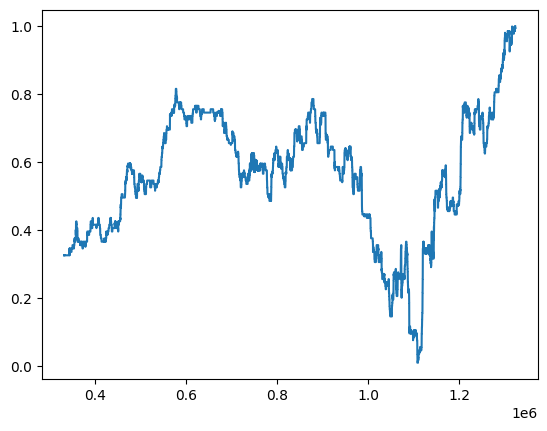

In [160]:
plt.plot(one_game_df_2.query('dt_pt > @start and dt_pt < @end')['mid'])

# Predexon

In [142]:
import json, requests

def get_clob_token_ids(slug: str) -> dict:
    """Returns {'yes': '<token_id>', 'no': '<token_id>'} for a Polymarket slug."""
    r = requests.get(
        f"https://gamma-api.polymarket.com/markets/slug/{slug}",
        params={"include_tag": "true"}, timeout=20,
    )
    r.raise_for_status()
    m = r.json()
    ids = m["clobTokenIds"]
    if isinstance(ids, str):           # gamma returns it stringified
        ids = json.loads(ids)
    outcomes = m.get("outcomes")
    if isinstance(outcomes, str):
        outcomes = json.loads(outcomes)
    # Sanity-check the YES/NO ordering using the outcomes field.
    print(f"question:  {m['question']}")
    print(f"outcomes:  {outcomes}      (index 0=YES, 1=NO)")
    print(f"conditionId: {m['conditionId']}")
    return {"yes": ids[0], "no": ids[1]}

tokens = get_clob_token_ids("nba-lal-okc-2026-05-07")  # replace with real slug

question:  Lakers vs. Thunder
outcomes:  ['Lakers', 'Thunder']      (index 0=YES, 1=NO)
conditionId: 0xacc23a9c2a560142bda18884949374d6a9d920b0e44c57b43bc4e8911727b01f


In [119]:
from __future__ import annotations

import json
import os
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path

import requests

API_URL = "https://api.predexon.com/v2/polymarket/orderbooks"

def fetch_orderbooks_streaming(token_id: str, start_ms: int, end_ms: int,
                               api_key: str, out_path: Path, *,
                               limit: int = 200,
                               sleep_between_pages: float = 0.05,
                               max_retries: int = 3) -> int:
    """Page through [start_ms, end_ms] and APPEND each snapshot to `out_path`
    as JSONL. Returns total snapshots written. Each page is flushed+fsync'd,
    so a crash loses at most the snapshots in the in-flight page."""
    headers = {"x-api-key": api_key}
    params = {
        "token_id":   token_id,
        "start_time": start_ms,
        "end_time":   end_ms,
        "limit":      limit,
    }
    n_total = 0
    page = 0
    with out_path.open("w") as f:
        while True:
            for attempt in range(max_retries):
                try:
                    r = requests.get(API_URL, headers=headers, params=params, timeout=30)
                    r.raise_for_status()
                    break
                except requests.RequestException as e:
                    if attempt == max_retries - 1:
                        raise
                    wait = 2 ** attempt
                    print(f"  [retry] {e}; sleeping {wait}s")
                    time.sleep(wait)
            data = r.json()
            snaps = data.get("snapshots", [])
            pagination = data.get("pagination", {})

            # ---- write THIS page to disk before doing anything else ----
            for s in snaps:
                f.write(json.dumps(s) + "\n")
            f.flush()
            os.fsync(f.fileno())  # belt + suspenders: survives kernel-level crash

            n_total += len(snaps)
            page += 1
            print(f"  page {page:>3}: +{len(snaps):>4} (total {n_total:,}, "
                  f"has_more={pagination.get('has_more')})")
            if not pagination.get("has_more"):
                break
            next_key = pagination.get("pagination_key")
            if not next_key:
                break
            params["pagination_key"] = next_key
            time.sleep(sleep_between_pages)
    return n_total


for label, token_id in tokens.items():
    if token_id.startswith("REPLACE"):
        print(f"Skipping {label}: token id not set.\n")
        continue
    print(f"Fetching {label} ({token_id[:12]}...)")
    out_path  = out_dir / f"okc_lal_2026-05-08_{label}.jsonl"
    meta_path = out_path.with_suffix(".meta.json")

    # Write metadata up front so a partial file is still interpretable.
    meta = {
        "token_id":   token_id,
        "label":      label,
        "start_ms":   start_ms,
        "end_ms":     end_ms,
        "started_at": datetime.now(timezone.utc).isoformat(),
        "status":     "in_progress",
    }
    meta_path.write_text(json.dumps(meta, indent=2))

    n = fetch_orderbooks_streaming(token_id, start_ms, end_ms, api_key,
                                   out_path, sleep_between_pages=0.5)

    # Finalize metadata.
    meta.update({
        "n_snapshots": n,
        "finished_at": datetime.now(timezone.utc).isoformat(),
        "status":      "complete",
    })
    meta_path.write_text(json.dumps(meta, indent=2))
    print(f"  -> wrote {n:,} snapshots to {out_path}\n")

def to_ms(dt: datetime) -> int:
    return int(dt.timestamp() * 1000)



Fetching yes (114717842397...)
  page   1: + 200 (total 200, has_more=True)
  page   2: + 200 (total 400, has_more=True)
  page   3: + 200 (total 600, has_more=True)
  page   4: + 200 (total 800, has_more=True)
  page   5: + 200 (total 1,000, has_more=True)
  page   6: + 200 (total 1,200, has_more=True)
  page   7: + 200 (total 1,400, has_more=True)
  page   8: + 200 (total 1,600, has_more=True)
  page   9: + 200 (total 1,800, has_more=True)
  page  10: + 200 (total 2,000, has_more=True)
  page  11: + 200 (total 2,200, has_more=True)
  page  12: + 200 (total 2,400, has_more=True)
  page  13: + 200 (total 2,600, has_more=True)
  page  14: + 200 (total 2,800, has_more=True)
  page  15: + 200 (total 3,000, has_more=True)
  page  16: + 200 (total 3,200, has_more=True)
  page  17: + 200 (total 3,400, has_more=True)
  page  18: + 200 (total 3,600, has_more=True)
  page  19: + 200 (total 3,800, has_more=True)
  page  20: + 200 (total 4,000, has_more=True)
  page  21: + 200 (total 4,200, has_m

In [120]:
out_path

PosixPath('data/raw/predexon/okc_lal_2026-05-08_no.jsonl')

In [121]:
snaps = [json.loads(line) for line in open(out_path)]      # eager
# or, for huge files:
def iter_snaps(p):
    with open(p) as f:
        for line in f:
            yield json.loads(line)


In [125]:
import json
import numpy as np
import pandas as pd

def snaps_to_df(snaps, k: int = 10) -> pd.DataFrame:
    """One row per snapshot, top-K levels per side as flat columns.

    Bids are sorted high-to-low (most aggressive first), asks low-to-high,
    so column index 1 is always best-of-book on each side. Missing levels
    (when a side has < k populated levels) are NaN.

    Columns: bid_px_1..K, bid_sz_1..K, ask_px_1..K, ask_sz_1..K,
             mid, spread, ts_ms, ts_dt, asset_id, market, hash
    """
    rows = []
    for s in snaps:
        bids = sorted(s["bids"], key=lambda x: x["price"], reverse=True)[:k]
        asks = sorted(s["asks"], key=lambda x: x["price"])[:k]
        row = {}
        for i in range(k):
            row[f"bid_px_{i+1}"] = bids[i]["price"] if i < len(bids) else np.nan
            row[f"bid_sz_{i+1}"] = bids[i]["size"]  if i < len(bids) else np.nan
            row[f"ask_px_{i+1}"] = asks[i]["price"] if i < len(asks) else np.nan
            row[f"ask_sz_{i+1}"] = asks[i]["size"]  if i < len(asks) else np.nan
        bb = bids[0]["price"] if bids else np.nan
        ba = asks[0]["price"] if asks else np.nan
        row["mid"]      = (bb + ba) / 2 if bids and asks else np.nan
        row["spread"]   = ba - bb       if bids and asks else np.nan
        row["ts_ms"]    = s["timestamp"]
        row["asset_id"] = s["assetId"]
        row["market"]   = s["market"]
        row["hash"]     = s["hash"]
        rows.append(row)
    df = pd.DataFrame(rows)
    df["ts_dt"] = pd.to_datetime(df["ts_ms"], unit="ms", utc=True)
    # Sensible column order: metadata + derived first, then book levels.
    meta = ["ts_ms", "ts_dt", "mid", "spread", "asset_id", "market", "hash"]
    level_cols = [c for c in df.columns if c not in meta]
    return df[meta + level_cols]

In [128]:
df.head(5)

,ts_ms,ts_dt,mid,spread,asset_id,market,hash,bid_px_1,bid_sz_1,ask_px_1,...,ask_px_8,ask_sz_8,bid_px_9,bid_sz_9,ask_px_9,ask_sz_9,bid_px_10,bid_sz_10,ask_px_10,ask_sz_10
0,1778137212932,2026-05-07 07:00:12.932000+00:00,0.875,0.01,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,bd29af624723917747df15b1cc7c63fdccb9d22d,0.87,165276.54,0.88,...,0.95,850.0,0.79,500.0,0.96,4482.36,0.78,506.45,0.97,5000.0
1,1778137239931,2026-05-07 07:00:39.931000+00:00,0.875,0.01,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,0c5be47d96becc8be8183ad4537e7fd83d42bf71,0.87,166276.54,0.88,...,0.95,850.0,0.79,500.0,0.96,4482.36,0.78,506.45,0.97,5000.0
2,1778137255381,2026-05-07 07:00:55.381000+00:00,0.875,0.01,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,4ddfbed6f024b5d8f9c03f41b615c0dc3ee3ed11,0.87,165546.38,0.88,...,0.95,850.0,0.79,500.0,0.96,4482.36,0.78,506.45,0.97,5000.0
3,1778137359660,2026-05-07 07:02:39.660000+00:00,0.875,0.01,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,7c11c2c0f1c8bce8ab7fabd13bbacb3670e66b99,0.87,165540.37,0.88,...,0.95,850.0,0.79,500.0,0.96,4482.36,0.78,506.45,0.97,5000.0
4,1778137467330,2026-05-07 07:04:27.330000+00:00,0.875,0.01,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,65a413a55545e98701f44ee7e3e6183908fe6425,0.87,164403.68,0.88,...,0.95,850.0,0.79,500.0,0.96,4482.36,0.78,506.45,0.97,5000.0


In [137]:
out_path

PosixPath('data/raw/predexon/okc_lal_2026-05-08_no.jsonl')

In [ ]:
with open(out_path) as f:
    snaps = [json.loads(line) for line in f]

df = snaps_to_df(snaps, k=10)
df_2 = df.copy()
df_2["dt_pt"] = (
    pd.to_datetime(df_2["ts_dt"], utc=True)
      .dt.tz_convert("America/Los_Angeles")
)
df_2

,ts_ms,ts_dt,mid,spread,asset_id,market,hash,bid_px_1,bid_sz_1,ask_px_1,...,ask_sz_8,bid_px_9,bid_sz_9,ask_px_9,ask_sz_9,bid_px_10,bid_sz_10,ask_px_10,ask_sz_10,dt_pt
0,1778137212932,2026-05-07 07:00:12.932000+00:00,0.875,0.01,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,bd29af624723917747df15b1cc7c63fdccb9d22d,0.870,165276.54,0.88,...,850.0,0.790,500.0,0.96,4482.36,0.780,506.45,0.97,5000.0,2026-05-07 00:00:12.932000-07:00
1,1778137239931,2026-05-07 07:00:39.931000+00:00,0.875,0.01,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,0c5be47d96becc8be8183ad4537e7fd83d42bf71,0.870,166276.54,0.88,...,850.0,0.790,500.0,0.96,4482.36,0.780,506.45,0.97,5000.0,2026-05-07 00:00:39.931000-07:00
2,1778137255381,2026-05-07 07:00:55.381000+00:00,0.875,0.01,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,4ddfbed6f024b5d8f9c03f41b615c0dc3ee3ed11,0.870,165546.38,0.88,...,850.0,0.790,500.0,0.96,4482.36,0.780,506.45,0.97,5000.0,2026-05-07 00:00:55.381000-07:00
3,1778137359660,2026-05-07 07:02:39.660000+00:00,0.875,0.01,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,7c11c2c0f1c8bce8ab7fabd13bbacb3670e66b99,0.870,165540.37,0.88,...,850.0,0.790,500.0,0.96,4482.36,0.780,506.45,0.97,5000.0,2026-05-07 00:02:39.660000-07:00
4,1778137467330,2026-05-07 07:04:27.330000+00:00,0.875,0.01,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,65a413a55545e98701f44ee7e3e6183908fe6425,0.870,164403.68,0.88,...,850.0,0.790,500.0,0.96,4482.36,0.780,506.45,0.97,5000.0,2026-05-07 00:04:27.330000-07:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11602,1778215941004,2026-05-08 04:52:21.004000+00:00,NaN,NaN,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,1609806559dcabfb1f8819f128b6940aa32fd16a,0.999,2214706.39,NaN,...,NaN,0.989,900.0,NaN,NaN,0.987,1500.00,NaN,NaN,2026-05-07 21:52:21.004000-07:00
11603,1778215961005,2026-05-08 04:52:41.005000+00:00,NaN,NaN,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,9ef5165fc1249dd7188199b549241f65dc80d625,0.999,2435969.00,NaN,...,NaN,0.989,900.0,NaN,NaN,0.987,1500.00,NaN,NaN,2026-05-07 21:52:41.005000-07:00
11604,1778215968011,2026-05-08 04:52:48.011000+00:00,NaN,NaN,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,b56f78092f17f7b49ebe7aebf2f2a4af387702f0,0.999,2435904.94,NaN,...,NaN,0.989,900.0,NaN,NaN,0.987,1500.00,NaN,NaN,2026-05-07 21:52:48.011000-07:00
11605,1778215970003,2026-05-08 04:52:50.003000+00:00,NaN,NaN,7448264333766943214843124704580426055651964420...,0xacc23a9c2a560142bda18884949374d6a9d920b0e44c...,b6bc0ad21f54ff86b53d3ee0ed23c700c84425dc,0.999,2435890.17,NaN,...,NaN,0.989,900.0,NaN,NaN,0.987,1500.00,NaN,NaN,2026-05-07 21:52:50.003000-07:00


In [133]:
start = datetime(2026, 5, 7, 18, 30, tzinfo=ZoneInfo("America/Los_Angeles"))
end = datetime(2026, 5, 7, 21, 0, tzinfo=ZoneInfo("America/Los_Angeles"))


df_2.query('dt_pt > @start and dt_pt < @end')['mid'].describe()

count    6353.000000
mean        0.845299
std         0.082990
min         0.655000
25%         0.775000
50%         0.885000
75%         0.908500
max         0.975000
Name: mid, dtype: float64

In [134]:
import json
import requests
from functools import lru_cache

GAMMA_BASE = "https://gamma-api.polymarket.com"

@lru_cache(maxsize=256)
def market_for_token(token_id: str) -> dict:
    """Look up market metadata by clobTokenId. Cached so it's free to
    call once per snapshot."""
    r = requests.get(f"{GAMMA_BASE}/markets",
                     params={"clob_token_ids": token_id}, timeout=20)
    r.raise_for_status()
    items = r.json()
    if not items:
        raise ValueError(f"No market found for token_id {token_id}")
    m = items[0] if isinstance(items, list) else items
    for k in ("outcomes", "outcomePrices", "clobTokenIds"):
        if k in m and isinstance(m[k], str):
            m[k] = json.loads(m[k])
    return m

def outcome_for_token(token_id: str) -> dict:
    m = market_for_token(token_id)
    idx = m["clobTokenIds"].index(token_id)
    return {
        "outcome":      m["outcomes"][idx],          # e.g. "Thunder" or "Yes"
        "counter":      m["outcomes"][1 - idx],      # the other side
        "index":        idx,                          # 0 = YES slot, 1 = NO slot
        "question":     m["question"],
        "condition_id": m["conditionId"],
        "all_outcomes": m["outcomes"],
    }

In [140]:
tokens

{'yes': '114717842397013009203642282246999859129015569597308997436247378109956177330871',
 'no': '74482643337669432148431247045804260556519644205220868565589251024815322037566'}

In [138]:
snaps[0]

{'asks': [{'size': 1007504.65, 'price': 0.99},
  {'size': 6457.6, 'price': 0.98},
  {'size': 5000.0, 'price': 0.97},
  {'size': 4482.36, 'price': 0.96},
  {'size': 850.0, 'price': 0.95},
  {'size': 8180.64, 'price': 0.94},
  {'size': 11691.8, 'price': 0.93},
  {'size': 30.0, 'price': 0.92},
  {'size': 53559.53, 'price': 0.91},
  {'size': 124933.43, 'price': 0.9},
  {'size': 462919.34, 'price': 0.89},
  {'size': 1064757.2, 'price': 0.88}],
 'bids': [{'size': 2001247.13, 'price': 0.01},
  {'size': 1100.0, 'price': 0.02},
  {'size': 5000.0, 'price': 0.03},
  {'size': 6.49, 'price': 0.04},
  {'size': 240.35, 'price': 0.09},
  {'size': 542.64, 'price': 0.1},
  {'size': 5.43, 'price': 0.11},
  {'size': 180.25, 'price': 0.17},
  {'size': 24.41, 'price': 0.18},
  {'size': 353.14, 'price': 0.19},
  {'size': 49.51, 'price': 0.2},
  {'size': 160.23, 'price': 0.26},
  {'size': 21.7, 'price': 0.27},
  {'size': 319.51, 'price': 0.28},
  {'size': 45.52, 'price': 0.29},
  {'size': 400.0, 'price': 0.34

In [136]:
info = outcome_for_token(snaps[0]["assetId"])
print(info["question"], "->", info["outcome"])
# e.g. "Will the Thunder beat the Lakers on 2026-05-08?" -> "Yes"
# or   "Lakers vs Thunder: who wins on 2026-05-08?"      -> "Thunder"

ValueError: No market found for token_id 74482643337669432148431247045804260556519644205220868565589251024815322037566